# Baseline 모델 — LightGBM · XGBoost · CatBoost · Ensemble
Team 반갑다모 | 2026.07.01

> Y_Class 직접 분류 | 튜닝 없이 순정 성능 비교 | A_31 / T_31+O_31 독립 모델

---

### 구성
| 섹션 | 내용 |
|------|------|
| 0 | 환경 설정 |
| 1 | 데이터 로드 & 피처 설정 |
| 2 | LightGBM Baseline |
| 3 | XGBoost Baseline |
| 4 | CatBoost Baseline |
| 5 | Ensemble (Soft Voting) |
| 6 | 모델 성능 비교 |
| 7 | 시각화 (Confusion Matrix + Feature Importance) |
| 8 | 인사이트 & 다음 단계 |

### 평가 기준
- **주지표**: Macro F1
- **보조지표**: Class 0 Recall (불량 미검출 방지) + Class 2 Recall
- **Accuracy 사용 금지** — Class 1이 다수라 의미 없음


## 0. 환경 설정

In [1]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'lightgbm', 'xgboost', 'catboost', 'koreanize-matplotlib', '-q'])

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, recall_score, confusion_matrix, classification_report
)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드 & 피처 설정

In [2]:
a31 = pd.read_csv('A_31_preprocessed.csv', low_memory=False)
t31 = pd.read_csv('TO_31_preprocessed.csv', low_memory=False)

DROP_COLS = ['PRODUCT_ID', 'Y_Class', 'Y_Quality', 'TIMESTAMP', 'PRODUCT_CODE']

def get_XY(df):
    drop = [c for c in DROP_COLS if c in df.columns]
    X = df.drop(columns=drop)
    y = df['Y_Class']
    return X, y

X_a, y_a = get_XY(a31)
X_t, y_t = get_XY(t31)

print(f'A_31     피처: {X_a.shape[1]}개 | 샘플: {X_a.shape[0]}행')
print(f'T_31+O_31 피처: {X_t.shape[1]}개 | 샘플: {X_t.shape[0]}행')
print(f'\nA_31 Y_Class 분포: {y_a.value_counts().sort_index().to_dict()}')
print(f'T_31+O_31 Y_Class 분포: {y_t.value_counts().sort_index().to_dict()}')

A_31     피처: 1966개 | 샘플: 316행
T_31+O_31 피처: 569개 | 샘플: 592행

A_31 Y_Class 분포: {0: 76, 1: 150, 2: 90}
T_31+O_31 Y_Class 분포: {0: 48, 1: 490, 2: 54}


## 공통 함수 정의

In [3]:
def evaluate(y_true, y_pred, label=''):
    f1  = f1_score(y_true, y_pred, average='macro')
    r0  = recall_score(y_true, y_pred, labels=[0], average='macro')
    r2  = recall_score(y_true, y_pred, labels=[2], average='macro')
    return {'label': label, 'macro_f1': f1, 'recall_0': r0, 'recall_2': r2}

def print_scores(scores):
    print(f"  Macro F1      : {scores['macro_f1']:.4f}")
    print(f"  Class 0 Recall: {scores['recall_0']:.4f}")
    print(f"  Class 2 Recall: {scores['recall_2']:.4f}")

# 결과 저장용
all_results = {'A_31': {}, 'T_31+O_31': {}}
all_oof     = {'A_31': {}, 'T_31+O_31': {}}
all_proba   = {'A_31': {}, 'T_31+O_31': {}}
all_imp     = {'A_31': {}, 'T_31+O_31': {}}
print('공통 함수 정의 완료')

공통 함수 정의 완료


---
## 2. LightGBM Baseline

- 결측값 native 처리 (impute 불필요)
- 트리 기반 — 스케일링 불필요


In [4]:
def run_lgbm(X, y, product_label, n_splits=5):
    print(f'\n[LightGBM - {product_label}]')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(y))
    proba = np.zeros((len(y), 3))
    imp = np.zeros(X.shape[1])

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            num_leaves=31, class_weight='balanced',
            random_state=42, verbose=-1
        )
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X_val)
        proba[val_idx] = model.predict_proba(X_val)
        imp += model.feature_importances_
        f1 = f1_score(y_val, oof[val_idx], average='macro')
        print(f'  Fold {fold+1}: Macro F1 = {f1:.4f}')

    scores = evaluate(y, oof, 'LightGBM')
    print_scores(scores)
    return oof, proba, imp/n_splits, scores

oof_lgb_a, proba_lgb_a, imp_lgb_a, res_lgb_a = run_lgbm(X_a, y_a, 'A_31')
oof_lgb_t, proba_lgb_t, imp_lgb_t, res_lgb_t = run_lgbm(X_t, y_t, 'T_31+O_31')
all_results['A_31']['LightGBM'] = res_lgb_a
all_results['T_31+O_31']['LightGBM'] = res_lgb_t
all_oof['A_31']['LightGBM'] = oof_lgb_a
all_oof['T_31+O_31']['LightGBM'] = oof_lgb_t
all_proba['A_31']['LightGBM'] = proba_lgb_a
all_proba['T_31+O_31']['LightGBM'] = proba_lgb_t
all_imp['A_31']['LightGBM'] = imp_lgb_a
all_imp['T_31+O_31']['LightGBM'] = imp_lgb_t


[LightGBM - A_31]
  Fold 1: Macro F1 = 0.7563
  Fold 2: Macro F1 = 0.5894
  Fold 3: Macro F1 = 0.7388
  Fold 4: Macro F1 = 0.6991
  Fold 5: Macro F1 = 0.7123
  Macro F1      : 0.6995
  Class 0 Recall: 0.6711
  Class 2 Recall: 0.7111

[LightGBM - T_31+O_31]
  Fold 1: Macro F1 = 0.6060
  Fold 2: Macro F1 = 0.5519
  Fold 3: Macro F1 = 0.6479
  Fold 4: Macro F1 = 0.6352
  Fold 5: Macro F1 = 0.6895
  Macro F1      : 0.6303
  Class 0 Recall: 0.3750
  Class 2 Recall: 0.3519


---
## 3. XGBoost Baseline

In [5]:
def run_xgb(X, y, product_label, n_splits=5):
    print(f'\n[XGBoost - {product_label}]')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(y))
    proba = np.zeros((len(y), 3))
    imp = np.zeros(X.shape[1])

    # XGBoost는 NaN native 처리 가능
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # 클래스 가중치 계산
        classes = sorted(y_tr.unique())
        class_counts = y_tr.value_counts()
        total = len(y_tr)
        sample_weights = y_tr.map(lambda c: total / (len(classes) * class_counts[c]))

        model = xgb.XGBClassifier(
            n_estimators=500, learning_rate=0.05,
            max_depth=6, random_state=42,
            eval_metric='mlogloss',
            early_stopping_rounds=50,
            verbosity=0
        )
        model.fit(X_tr, y_tr,
                  sample_weight=sample_weights,
                  eval_set=[(X_val, y_val)],
                  verbose=False)
        oof[val_idx] = model.predict(X_val)
        proba[val_idx] = model.predict_proba(X_val)
        imp += model.feature_importances_
        f1 = f1_score(y_val, oof[val_idx], average='macro')
        print(f'  Fold {fold+1}: Macro F1 = {f1:.4f}')

    scores = evaluate(y, oof, 'XGBoost')
    print_scores(scores)
    return oof, proba, imp/n_splits, scores

oof_xgb_a, proba_xgb_a, imp_xgb_a, res_xgb_a = run_xgb(X_a, y_a, 'A_31')
oof_xgb_t, proba_xgb_t, imp_xgb_t, res_xgb_t = run_xgb(X_t, y_t, 'T_31+O_31')
all_results['A_31']['XGBoost'] = res_xgb_a
all_results['T_31+O_31']['XGBoost'] = res_xgb_t
all_oof['A_31']['XGBoost'] = oof_xgb_a
all_oof['T_31+O_31']['XGBoost'] = oof_xgb_t
all_proba['A_31']['XGBoost'] = proba_xgb_a
all_proba['T_31+O_31']['XGBoost'] = proba_xgb_t
all_imp['A_31']['XGBoost'] = imp_xgb_a
all_imp['T_31+O_31']['XGBoost'] = imp_xgb_t


[XGBoost - A_31]
  Fold 1: Macro F1 = 0.7228
  Fold 2: Macro F1 = 0.5584
  Fold 3: Macro F1 = 0.6950
  Fold 4: Macro F1 = 0.7926
  Fold 5: Macro F1 = 0.6826
  Macro F1      : 0.6913
  Class 0 Recall: 0.6447
  Class 2 Recall: 0.6667

[XGBoost - T_31+O_31]
  Fold 1: Macro F1 = 0.5738
  Fold 2: Macro F1 = 0.4821
  Fold 3: Macro F1 = 0.6855
  Fold 4: Macro F1 = 0.6506
  Fold 5: Macro F1 = 0.6566
  Macro F1      : 0.6135
  Class 0 Recall: 0.3333
  Class 2 Recall: 0.3704


---
## 4. CatBoost Baseline

> CatBoost는 범주형 피처를 자동으로 처리하고 NaN도 native 처리 가능

In [6]:
def run_catboost(X, y, product_label, n_splits=5):
    print(f'\n[CatBoost - {product_label}]')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(y))
    proba = np.zeros((len(y), 3))
    imp = np.zeros(X.shape[1])

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model = CatBoostClassifier(
            iterations=500, learning_rate=0.05,
            depth=6, auto_class_weights='Balanced',
            random_seed=42, verbose=0,
            early_stopping_rounds=50
        )
        model.fit(X_tr, y_tr,
                  eval_set=(X_val, y_val),
                  verbose=False)
        oof[val_idx] = model.predict(X_val).flatten()
        proba[val_idx] = model.predict_proba(X_val)
        imp += model.get_feature_importance()
        f1 = f1_score(y_val, oof[val_idx], average='macro')
        print(f'  Fold {fold+1}: Macro F1 = {f1:.4f}')

    scores = evaluate(y, oof, 'CatBoost')
    print_scores(scores)
    return oof, proba, imp/n_splits, scores

oof_cat_a, proba_cat_a, imp_cat_a, res_cat_a = run_catboost(X_a, y_a, 'A_31')
oof_cat_t, proba_cat_t, imp_cat_t, res_cat_t = run_catboost(X_t, y_t, 'T_31+O_31')
all_results['A_31']['CatBoost'] = res_cat_a
all_results['T_31+O_31']['CatBoost'] = res_cat_t
all_oof['A_31']['CatBoost'] = oof_cat_a
all_oof['T_31+O_31']['CatBoost'] = oof_cat_t
all_proba['A_31']['CatBoost'] = proba_cat_a
all_proba['T_31+O_31']['CatBoost'] = proba_cat_t
all_imp['A_31']['CatBoost'] = imp_cat_a
all_imp['T_31+O_31']['CatBoost'] = imp_cat_t


[CatBoost - A_31]
  Fold 1: Macro F1 = 0.7098
  Fold 2: Macro F1 = 0.5444
  Fold 3: Macro F1 = 0.6941
  Fold 4: Macro F1 = 0.7770
  Fold 5: Macro F1 = 0.6658
  Macro F1      : 0.6782
  Class 0 Recall: 0.6579
  Class 2 Recall: 0.6556

[CatBoost - T_31+O_31]
  Fold 1: Macro F1 = 0.6254
  Fold 2: Macro F1 = 0.5787
  Fold 3: Macro F1 = 0.5639
  Fold 4: Macro F1 = 0.6641
  Fold 5: Macro F1 = 0.7011
  Macro F1      : 0.6253
  Class 0 Recall: 0.4375
  Class 2 Recall: 0.4074


---
## 5. Ensemble (Soft Voting)

세 모델의 확률값 평균으로 최종 예측
- Soft Voting: 각 클래스 확률 평균 후 argmax
- 단순 평균 (가중치 없음) — Baseline 목적


In [7]:
def run_ensemble(proba_dict, y, product_label):
    print(f'\n[Ensemble - {product_label}]')
    # 세 모델 확률 평균
    avg_proba = np.mean(list(proba_dict.values()), axis=0)
    oof = np.argmax(avg_proba, axis=1)
    scores = evaluate(y, oof, 'Ensemble')
    print_scores(scores)
    return oof, avg_proba, scores

oof_ens_a, proba_ens_a, res_ens_a = run_ensemble(all_proba['A_31'], y_a, 'A_31')
oof_ens_t, proba_ens_t, res_ens_t = run_ensemble(all_proba['T_31+O_31'], y_t, 'T_31+O_31')
all_results['A_31']['Ensemble'] = res_ens_a
all_results['T_31+O_31']['Ensemble'] = res_ens_t
all_oof['A_31']['Ensemble'] = oof_ens_a
all_oof['T_31+O_31']['Ensemble'] = oof_ens_t


[Ensemble - A_31]
  Macro F1      : 0.7025
  Class 0 Recall: 0.6711
  Class 2 Recall: 0.6778

[Ensemble - T_31+O_31]
  Macro F1      : 0.6358
  Class 0 Recall: 0.3750
  Class 2 Recall: 0.3519


---
## 6. 모델 성능 비교

In [8]:
print('=' * 65)
print('모델 성능 비교')
print('=' * 65)

for product in ['A_31', 'T_31+O_31']:
    print(f'\n[{product}]')
    print(f"  {'모델':12} {'Macro F1':>10} {'Class0 Recall':>14} {'Class2 Recall':>14}")
    print(f"  {'-'*55}")
    for model_name, scores in all_results[product].items():
        marker = ' <<' if scores['macro_f1'] == max(
            s['macro_f1'] for s in all_results[product].values()) else ''
        print(f"  {model_name:12} {scores['macro_f1']:>10.4f} "
              f"{scores['recall_0']:>14.4f} {scores['recall_2']:>14.4f}{marker}")

모델 성능 비교

[A_31]
  모델             Macro F1  Class0 Recall  Class2 Recall
  -------------------------------------------------------
  LightGBM         0.6995         0.6711         0.7111
  XGBoost          0.6913         0.6447         0.6667
  CatBoost         0.6782         0.6579         0.6556
  Ensemble         0.7025         0.6711         0.6778 <<

[T_31+O_31]
  모델             Macro F1  Class0 Recall  Class2 Recall
  -------------------------------------------------------
  LightGBM         0.6303         0.3750         0.3519
  XGBoost          0.6135         0.3333         0.3704
  CatBoost         0.6253         0.4375         0.4074
  Ensemble         0.6358         0.3750         0.3519 <<


---
## 7. 시각화

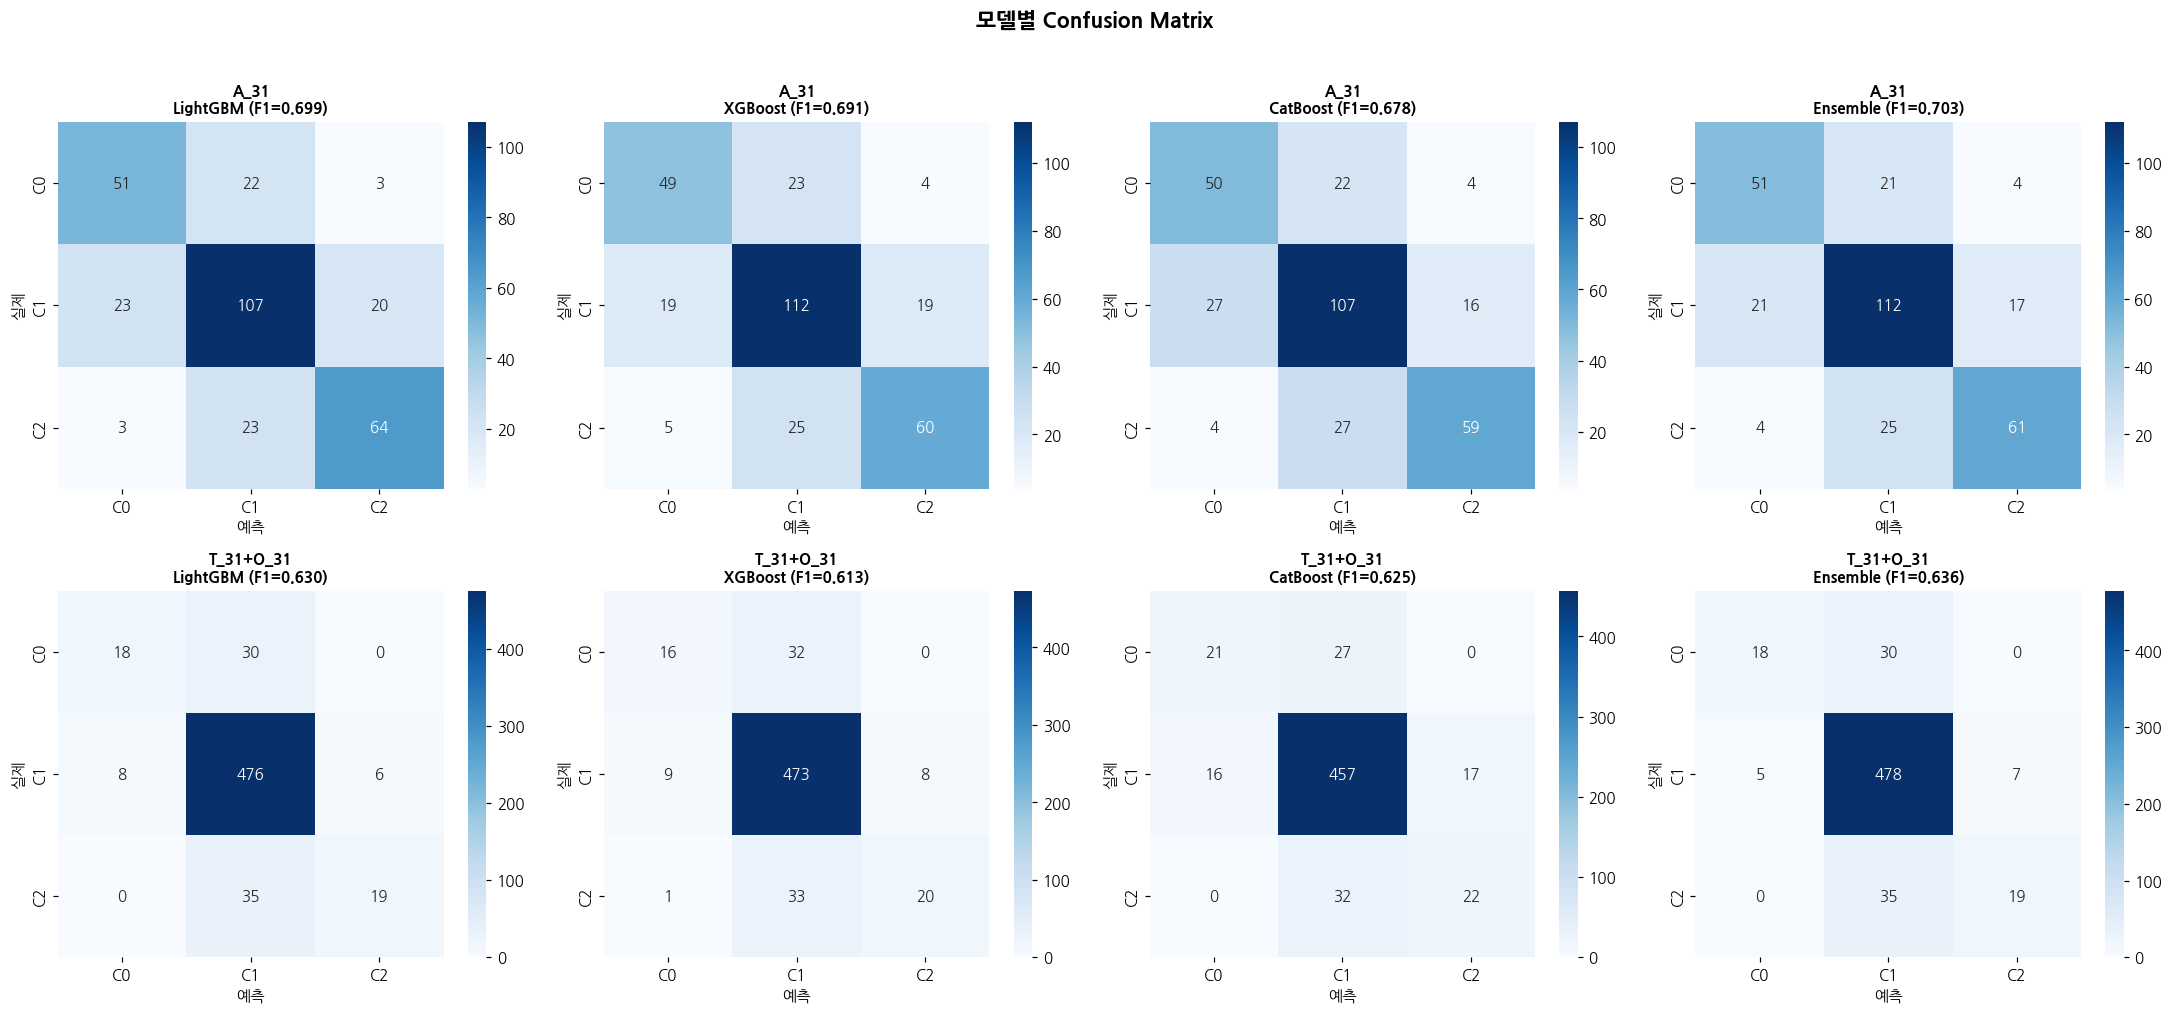

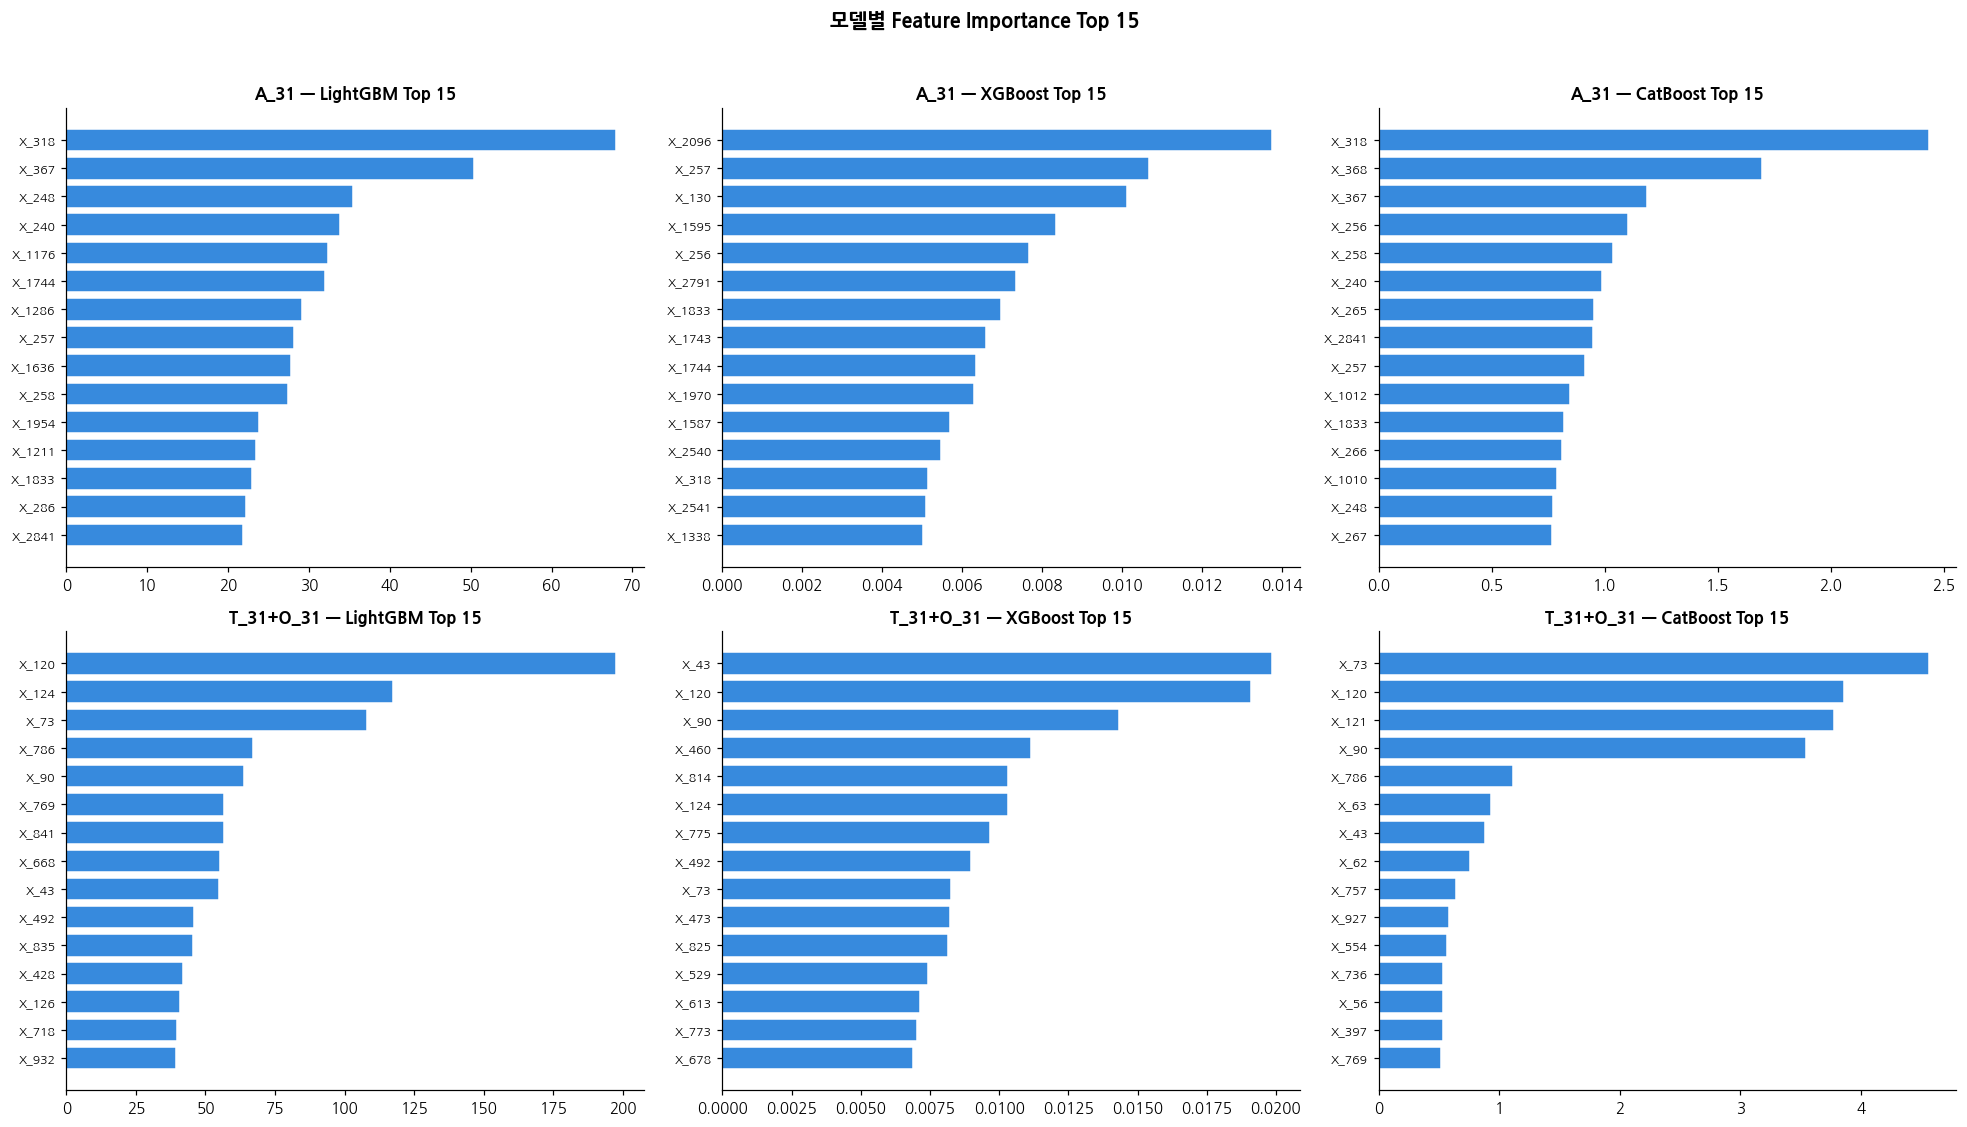

In [9]:
# Confusion Matrix 4개 (LGB·XGB·CAT·ENS) x 2 제품
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
model_names = ['LightGBM', 'XGBoost', 'CatBoost', 'Ensemble']

for row, (product, y) in enumerate([('A_31', y_a), ('T_31+O_31', y_t)]):
    oofs = [
        all_oof[product]['LightGBM'],
        all_oof[product]['XGBoost'],
        all_oof[product]['CatBoost'],
        all_oof[product]['Ensemble'],
    ]
    for col, (name, oof) in enumerate(zip(model_names, oofs)):
        ax = axes[row, col]
        cm = confusion_matrix(y, oof)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['C0','C1','C2'],
                    yticklabels=['C0','C1','C2'])
        f1 = all_results[product][name]['macro_f1']
        ax.set_title(f'{product}\n{name} (F1={f1:.3f})', fontsize=10, fontweight='bold')
        ax.set_ylabel('실제')
        ax.set_xlabel('예측')

plt.suptitle('모델별 Confusion Matrix', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Feature Importance 비교 (Top 15)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
imp_models = ['LightGBM', 'XGBoost', 'CatBoost']

for row, (product, X) in enumerate([('A_31', X_a), ('T_31+O_31', X_t)]):
    for col, name in enumerate(imp_models):
        ax = axes[row, col]
        imp = all_imp[product][name]
        imp_df = pd.DataFrame({'feature': X.columns, 'importance': imp})
        imp_df = imp_df.sort_values('importance', ascending=False).head(15)
        ax.barh(range(len(imp_df)), imp_df['importance'].values,
                color='#378ADD', edgecolor='white')
        ax.set_yticks(range(len(imp_df)))
        ax.set_yticklabels(imp_df['feature'].values, fontsize=8)
        ax.invert_yaxis()
        ax.set_title(f'{product} — {name} Top 15', fontsize=11, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle('모델별 Feature Importance Top 15', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. 인사이트 & 다음 단계

In [10]:
print('=' * 55)
print('Baseline 종합 인사이트')
print('=' * 55)

for product in ['A_31', 'T_31+O_31']:
    best_model = max(all_results[product].items(), key=lambda x: x[1]['macro_f1'])
    print(f'\n[{product}] 최고 모델: {best_model[0]} (Macro F1: {best_model[1]["macro_f1"]:.4f})')
    f1 = best_model[1]['macro_f1']
    if f1 >= 0.7:
        print('  -> 양호. Optuna 튜닝으로 추가 개선 가능')
    elif f1 >= 0.5:
        print('  -> 보통. 피처 선택 + 튜닝 필요')
    else:
        print('  -> 낮음. 피처 선택 / 불균형 처리 재검토 필요')

print('\n' + '=' * 55)
print('다음 단계')
print('=' * 55)
print('  1. Optuna 하이퍼파라미터 튜닝 (최고 모델 기준)')
print('  2. Feature Importance 기반 피처 선택')
print('  3. SMOTE 불균형 처리 실험')
print('  4. SHAP 분석 -> H1~H4 가설 검증')
print('  5. 앙상블 가중치 최적화')

Baseline 종합 인사이트

[A_31] 최고 모델: Ensemble (Macro F1: 0.7025)
  -> 양호. Optuna 튜닝으로 추가 개선 가능

[T_31+O_31] 최고 모델: Ensemble (Macro F1: 0.6358)
  -> 보통. 피처 선택 + 튜닝 필요

다음 단계
  1. Optuna 하이퍼파라미터 튜닝 (최고 모델 기준)
  2. Feature Importance 기반 피처 선택
  3. SMOTE 불균형 처리 실험
  4. SHAP 분석 -> H1~H4 가설 검증
  5. 앙상블 가중치 최적화
